<a href="https://colab.research.google.com/github/abdulrasheedmd2005/Week4-DataScience-Tasks/blob/main/Sales_Forecasting_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Superstore.csv to Superstore.csv


In [3]:
df = pd.read_csv("Superstore.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df=df.dropna()

In [9]:
df=df.drop_duplicates()

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)

In [12]:
df['Order Date']

,Order Date
0,2017-11-08
1,2017-11-08
2,2017-06-12
3,2016-10-11
4,2016-10-11
...,...
9795,2017-05-21
9796,2016-01-12
9797,2016-01-12
9798,2016-01-12


In [13]:
df['Month'] = df['Order Date'].dt.month

In [14]:
df['Year'] = df['Order Date'].dt.year

In [15]:
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

In [16]:
df.describe()

,Row ID,Order Date,Postal Code,Sales,Month,Year,DayOfWeek
count,9789.000000,9789,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000
mean,4896.705588,2017-05-01 02:51:57.866993664,55273.322403,230.116193,7.822658,2016.723567,2.994790
min,1.000000,2015-01-03 00:00:00,1040.000000,0.444000,1.000000,2015.000000,0.000000
25%,2449.000000,2016-05-23 00:00:00,23223.000000,17.248000,5.000000,2016.000000,1.000000
50%,4896.000000,2017-06-26 00:00:00,58103.000000,54.384000,9.000000,2017.000000,3.000000
75%,7344.000000,2018-05-15 00:00:00,90008.000000,210.392000,11.000000,2018.000000,5.000000
max,9800.000000,2018-12-30 00:00:00,99301.000000,22638.480000,12.000000,2018.000000,6.000000
std,2827.486899,NaN,32041.223413,625.302079,3.277864,1.124184,2.180615


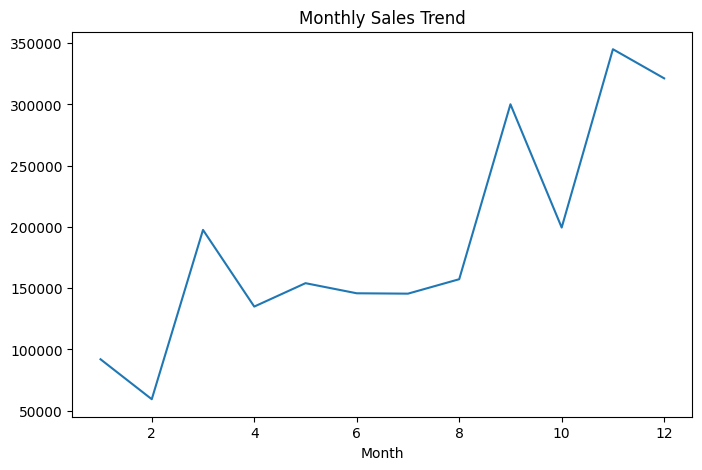

In [17]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line',figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.show()

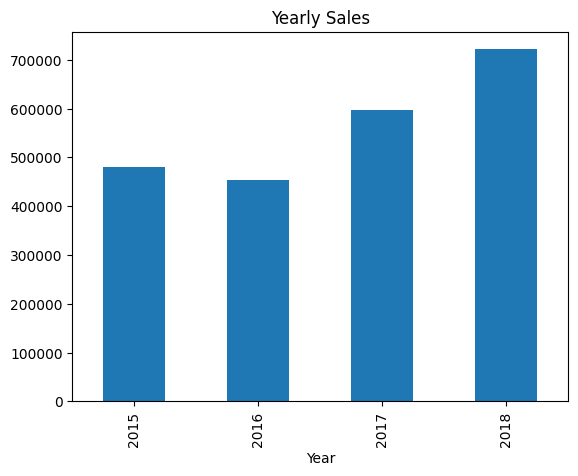

In [18]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales")
plt.show()

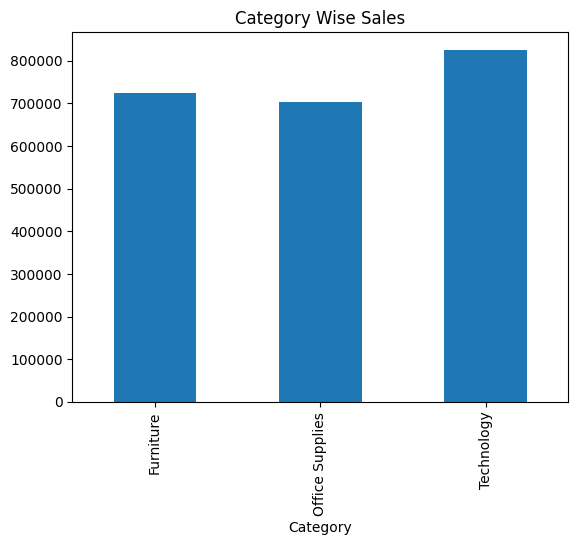

In [19]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.title("Category Wise Sales")
plt.show()

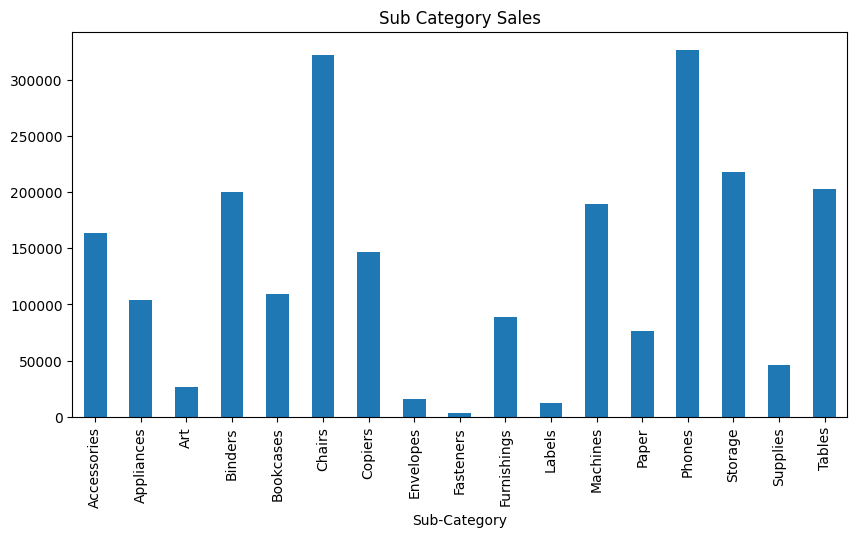

In [20]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum()
subcategory_sales.plot(kind='bar',figsize=(10,5))
plt.title("Sub Category Sales")
plt.show()

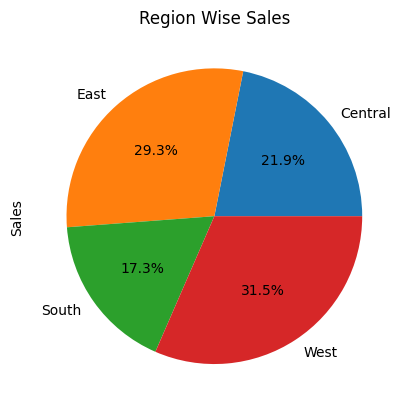

In [21]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title("Region Wise Sales")
plt.show()

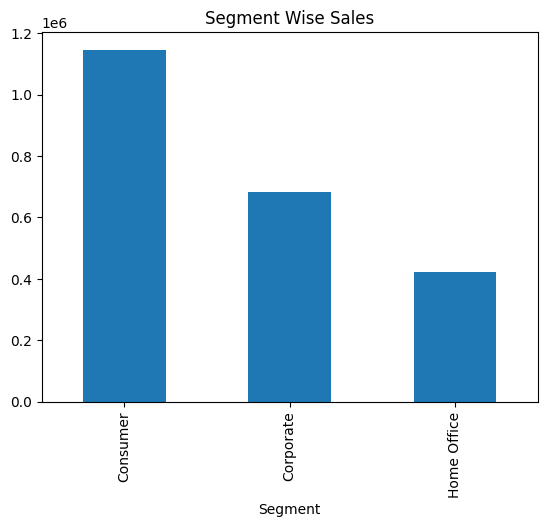

In [22]:
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='bar')
plt.title("Segment Wise Sales")
plt.show()

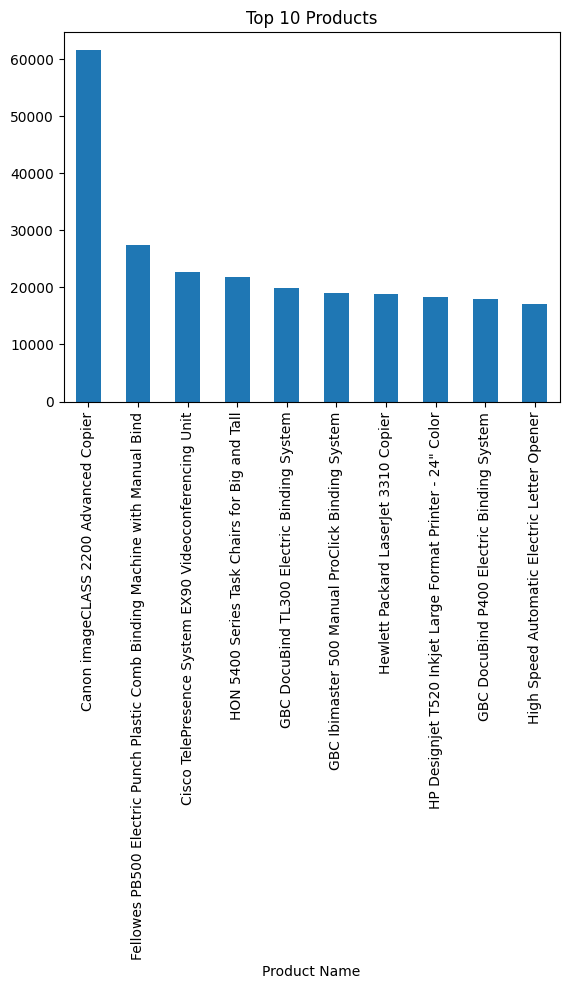

In [23]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

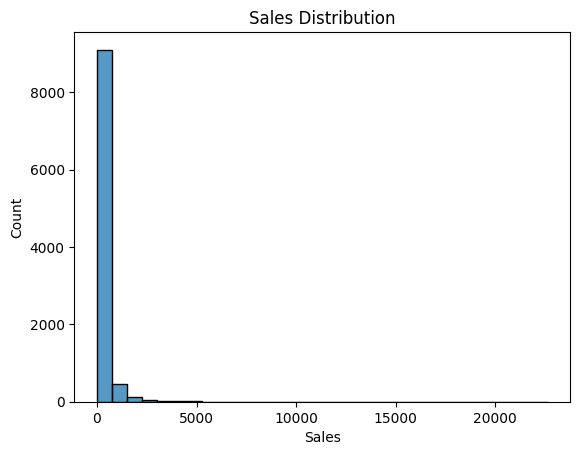

In [24]:
sns.histplot(df['Sales'],bins=30)
plt.title("Sales Distribution")
plt.show()

In [25]:
encoder = LabelEncoder()
df['Category'] = encoder.fit_transform(df['Category'])

In [26]:
df['Sub-Category'] = encoder.fit_transform(df['Sub-Category'])

In [27]:
df['Region'] = encoder.fit_transform(df['Region'])

In [28]:
df['Segment'] = encoder.fit_transform(df['Segment'])

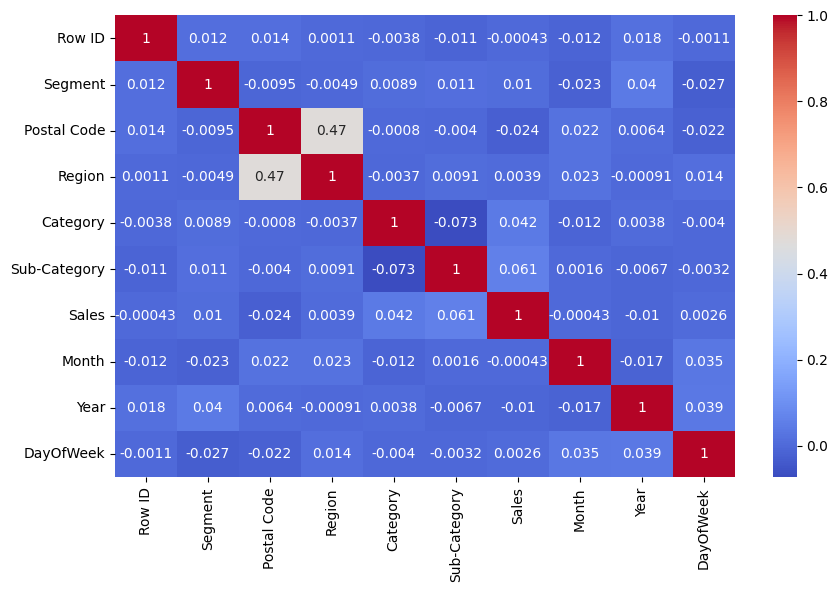

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap='coolwarm')
plt.show()

In [30]:
X = df[['Month','Year','Region','Category','Sub-Category','Segment']]

In [31]:
y = df['Sales']

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
model = LinearRegression()

In [34]:
model.fit(X_train,y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE =", mae)

MAE = 283.24304851795773


In [37]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE =", rmse)

RMSE = 697.2237883652751


In [38]:
r2 = r2_score(y_test,y_pred)
print("R2 Score =", r2)

R2 Score = 0.00615929682087657


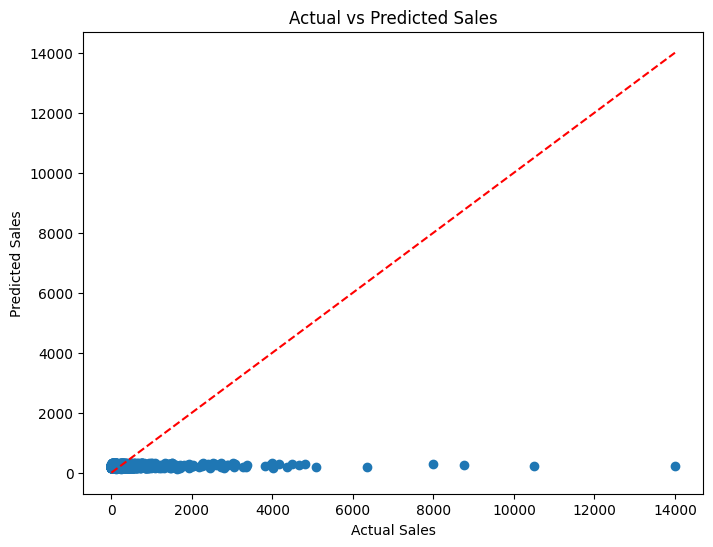

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# Business Insights

1. Technology and Office Supplies categories contributed significantly to sales.

2. Certain regions generated higher revenue than others.

3. Sales varied across customer segments.

4. Some products consistently outperformed others.

5. Historical sales trends can help forecast future business performance.

# Model Evaluation

The Linear Regression model achieved a low R² score (0.006), indicating that the selected features have limited predictive power for forecasting sales.

This may be due to the absence of important business variables such as quantity sold, discounts, product pricing, and profit-related information.

Future improvements can be made by incorporating additional sales-related features and trying advanced machine learning models.

The Actual vs Predicted Sales plot shows that predicted values are concentrated within a narrow range while actual sales vary significantly.

This indicates that the model struggles to capture large variations in sales and tends to predict average sales values.

The visualization confirms the low R² score obtained during model evaluation.

# Conclusion

A Sales Forecasting and Business Analytics System was successfully developed using Machine Learning.

The project included:
- Data Cleaning
- EDA
- Feature Engineering
- Data Visualization
- Sales Forecasting
- Business Analytics

The model can help businesses forecast future sales and support better decision-making.